In [2]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Library for profiling
from ydata_profiling import ProfileReport

# visual configuration
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Data paths
TRAIN_PATH = "../data/raw/train.csv"
TEST_PATH = "../data/raw/test.csv"

# Load the data
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Train set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")
df_train.head()

Train set shape: (243787, 21)
Test set shape: (104480, 20)


,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [12]:

# 1. verify missing values
missing_values = df_train.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percent})
print("--- Missing Values ---")
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

# 2. verify duplicates
duplicates = df_train.duplicated().sum()
print(f"\n--- Duplicates ---")
print(f"Number of duplicate rows: {duplicates}")

# 3. verify data types
print("\n--- Data Types Requiring Attention  ---")
print(df_train.dtypes.value_counts())

--- Missing Values ---
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []

--- Duplicates ---
Number of duplicate rows: 0

--- Data Types Requiring Attention  ---
object     11
int64       5
float64     5
Name: count, dtype: int64


In [10]:
# cell for generating the data profiling report
# Attention : take 1 to 2 minutes to generate the report depending on the size of the dataset

print("Generating Data Profiling Report...")
profile = ProfileReport(df_train, title="SaaS Churn Data Profiling Report", explorative=True)

# Save the report to an HTML file
profile.to_file("../reports/figures/data_profile_train.html")
print("Report generated and saved under: '../reports/figures/data_profile_train.html'")

# Optionnel : for displaying the report in a Jupyter Notebook (uncomment the line below if using a notebook)
# profile.to_widgets()

Generating Data Profiling Report...


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 34.65it/s]

Report generated and saved under: '../reports/figures/data_profile_train.html'


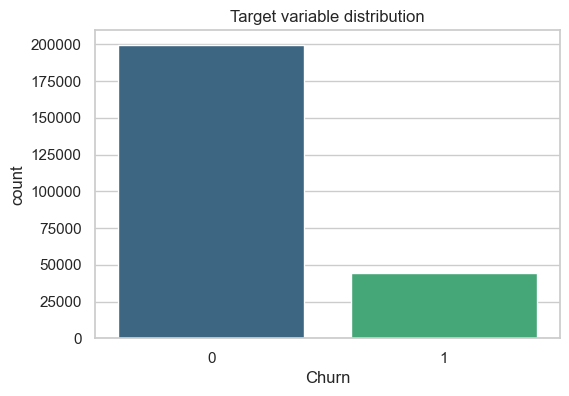

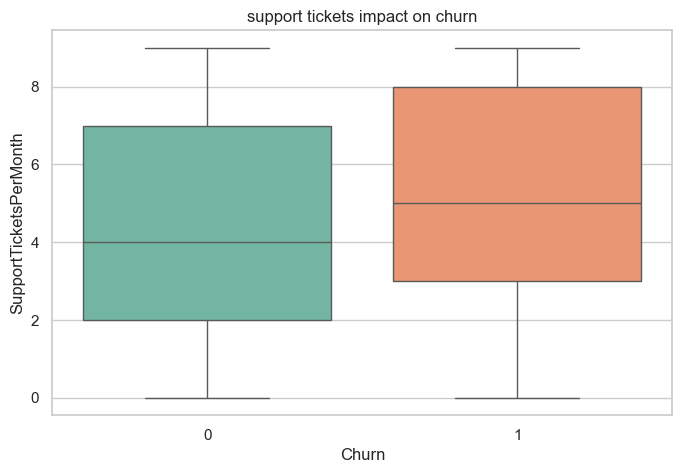

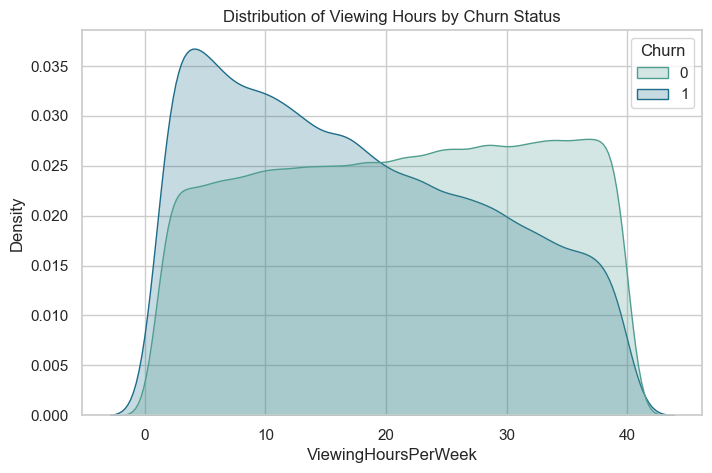

In [14]:
TARGET = 'Churn' 

if TARGET in df_train.columns:
    # 1. Overall churn rate
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_train, x=TARGET, palette='viridis')
    plt.title('Target variable distribution')

    plt.savefig('../reports/figures/01_target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


    # 2. support tickets impact on churn
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_train, x=TARGET, y='SupportTicketsPerMonth', palette='Set2')
    plt.title('support tickets impact on churn')

    plt.savefig('../reports/figures/02_support_tickets_impact_churn.png', dpi=300, bbox_inches='tight')
    plt.show()


    # 3. Viewing hours impact on churn
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df_train, x='ViewingHoursPerWeek', hue=TARGET, fill=True, common_norm=False, palette='crest')
    plt.title('Distribution of Viewing Hours by Churn Status')

    plt.savefig('../reports/figures/03_viewing_hours_impact_churn.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print(f" '{TARGET}' not found. Please verify its exact name (e.g., 'Churn_Yes').")

### 3. Target Variable & Bivariate Analysis (Visual Insights)

Based on the visual exploratory data analysis, we have identified critical behavioral patterns that differentiate retained customers from those who churn.

**1. Target Variable Distribution (Class Imbalance)**
* The dataset exhibits a moderate class imbalance.
* **Retained (Class 0):** ~200,000 customers (approx. 82% of the dataset).
* **Churned (Class 1):** ~43,700 customers (approx. 18% of the dataset).
* **Strategic Impact:** Because the classes are imbalanced, we cannot rely solely on "Accuracy" as an evaluation metric. We will need to prioritize **Recall** (to catch as many churners as possible) and the **F1-Score**, and ensure we use stratified sampling during our train/test split.

**2. Friction and Frustration (Support Tickets)**
* The boxplot comparing `SupportTicketsPerMonth` against the `Churn` status shows a clear upward shift for churned customers.
* The median number of support tickets for retained customers is 4, whereas it shifts to 5 for churned customers. The 75th percentile also shifts from 7 up to 8 tickets.
* **Strategic Impact:** While not a massive gap, higher support interactions indicate user friction. Customers requiring constant support are at a higher risk of canceling their subscription.

**3. Product Engagement (Viewing Hours) - 🚨 Strongest Signal**
* The KDE (Density) plot for `ViewingHoursPerWeek` reveals a stark contrast in user behavior.
* **Retained Customers:** Exhibit a very flat, uniform distribution, maintaining steady engagement anywhere from 5 to 40 hours a week.
* **Churned Customers:** The distribution is heavily left-skewed, with a massive density peak at the lower end (around 3 to 5 hours per week).
* **Strategic Impact:** Low product usage is the most profound indicator of churn. Customers who do not spend time on the platform lose perceived value and cancel. This variable will likely be the most important feature (Feature Importance) in our predictive model.